In [87]:
import numpy as np
from io import StringIO

# proliferating e-anyons, m-anyons subthreshold

data_str1 = """ 0.349000 0.416000 0.507000 0.596250 0.677375 0.758125 0.817000 0.871000
0.340375 0.427250 0.504000 0.596625 0.672250 0.751500 0.810875 0.869125
0.339750 0.418750 0.509250 0.603875 0.675500 0.748000 0.820625 0.872625
0.357875 0.426375 0.495875 0.600250 0.674625 0.745375 0.818000 0.866625
0.304500 0.375625 0.493125 0.578000 0.689375 0.772000 0.839500 0.896875
0.299250 0.383875 0.471375 0.584250 0.681250 0.774000 0.840750 0.896000
0.309375 0.394000 0.478125 0.576625 0.689500 0.765750 0.840750 0.891875
0.307000 0.382625 0.489625 0.580875 0.686500 0.766875 0.845375 0.899000
0.258375 0.349000 0.458625 0.566750 0.692250 0.787000 0.865500 0.920125
0.260000 0.360875 0.464875 0.576875 0.689125 0.793875 0.868250 0.915375
0.261125 0.343625 0.466375 0.579250 0.682250 0.793750 0.859875 0.919375
0.254500 0.351500 0.453625 0.581375 0.688375 0.791000 0.867500 0.914750
0.233000 0.318625 0.428750 0.570125 0.691375 0.787000 0.878625 0.929375
0.231625 0.317875 0.436250 0.572250 0.686625 0.801500 0.877000 0.933125
0.230375 0.315875 0.433875 0.572375 0.697750 0.803875 0.880375 0.933375
0.227625 0.320125 0.427875 0.560375 0.701500 0.802875 0.880750 0.935500 """
data_str2 = """ 0.343000 0.426250 0.496875 0.605375 0.685875 0.748125 0.826375 0.868375
0.346375 0.413500 0.502750 0.585125 0.684250 0.750375 0.816000 0.864750
0.348375 0.425500 0.498625 0.577250 0.686000 0.743625 0.819500 0.870000
0.346250 0.429375 0.497000 0.596500 0.679500 0.755750 0.820375 0.864125
0.308250 0.379375 0.480375 0.580500 0.678375 0.773375 0.841250 0.899875
0.307000 0.387750 0.487250 0.574625 0.679250 0.765625 0.835500 0.892500
0.306500 0.383000 0.478875 0.587125 0.679125 0.764250 0.842750 0.891000
0.292500 0.373000 0.462125 0.583125 0.677750 0.775125 0.835875 0.894750
0.262875 0.340500 0.459625 0.572250 0.685500 0.786500 0.866625 0.916375
0.264625 0.340000 0.467125 0.569125 0.689625 0.790750 0.867250 0.914625
0.261000 0.350500 0.457625 0.573125 0.695875 0.784500 0.858125 0.919375
0.267750 0.353625 0.463750 0.582500 0.688000 0.783125 0.864625 0.911500
0.224250 0.315750 0.432625 0.571875 0.696375 0.799625 0.878625 0.925000
0.231625 0.313125 0.440125 0.571750 0.700375 0.804500 0.881250 0.931875
0.233875 0.319875 0.426500 0.570500 0.693000 0.811500 0.885375 0.932000
0.223250 0.321375 0.426250 0.575250 0.697125 0.799125 0.880500 0.938500 """
data_str3 = """ 0.347750 0.427250 0.494875 0.596125 0.684000 0.750000 0.813750 0.864375
0.344125 0.430375 0.515000 0.592875 0.681250 0.752625 0.809625 0.861375
0.347625 0.426375 0.503125 0.598000 0.676250 0.753125 0.813750 0.867875
0.347750 0.418625 0.499000 0.587500 0.671875 0.758875 0.813875 0.868000
0.294750 0.380750 0.485125 0.589625 0.689500 0.775125 0.840625 0.896500
0.301750 0.386250 0.483750 0.587000 0.682750 0.770500 0.843500 0.896000
0.296875 0.380625 0.480625 0.576625 0.691000 0.773125 0.846625 0.895750
0.294000 0.381750 0.474875 0.580500 0.683875 0.776125 0.843000 0.895875
0.258250 0.343375 0.455625 0.571500 0.701375 0.793250 0.864250 0.916375
0.253875 0.352125 0.454375 0.575500 0.680750 0.792125 0.865875 0.917125
0.256875 0.343750 0.457000 0.584750 0.691125 0.792750 0.861750 0.916375
0.259750 0.345875 0.459250 0.579250 0.692625 0.775875 0.860125 0.913375
0.229875 0.325500 0.440875 0.574125 0.694875 0.808250 0.880250 0.929375
0.232750 0.315625 0.442625 0.564125 0.695500 0.812125 0.884250 0.927750
0.228125 0.306875 0.434500 0.566250 0.699125 0.799875 0.879125 0.933125
0.226625 0.312250 0.434125 0.557375 0.701625 0.801250 0.880125 0.930125 """
# data_str4 = """ 0.345000 0.428250 0.495750 0.579000 0.675875 0.754125 0.825500 0.872375
# 0.343500 0.421500 0.505250 0.601250 0.670500 0.750250 0.817000 0.871750
# 0.343500 0.421500 0.502625 0.599875 0.683750 0.747500 0.820125 0.871250
# 0.349625 0.422125 0.493000 0.588625 0.681875 0.754500 0.815000 0.863625
# 0.299750 0.386500 0.480500 0.582875 0.680125 0.772875 0.846625 0.894875
# 0.302625 0.378875 0.478875 0.590125 0.689250 0.765750 0.844125 0.898625
# 0.300875 0.380625 0.480000 0.589875 0.685250 0.766375 0.848625 0.900125
# 0.302750 0.389625 0.484250 0.581500 0.687750 0.773625 0.851250 0.894000
# 0.261125 0.349125 0.448000 0.570375 0.694875 0.801500 0.874250 0.914500
# 0.264375 0.350500 0.446375 0.578000 0.696500 0.796750 0.867250 0.916000
# 0.267500 0.351250 0.463625 0.577000 0.699750 0.788875 0.864500 0.914125
# 0.256625 0.349750 0.455875 0.579625 0.692250 0.791625 0.867625 0.919250
# 0.236375 0.322000 0.455125 0.572250 0.696500 0.808625 0.886625 0.933250
# 0.232000 0.318625 0.439125 0.579125 0.699750 0.808125 0.888500 0.934250
# 0.228250 0.319750 0.433625 0.565250 0.705750 0.812000 0.885875 0.934500
# 0.236875 0.310500 0.441375 0.571500 0.700250 0.808500 0.889125 0.932750 """
# data_str5 = """ 0.641500 0.648200 0.679900 0.684100 0.702200 0.723600 0.740900 0.752400
# 0.645700 0.650700 0.674500 0.689300 0.707800 0.723600 0.740800 0.752100
# 0.635000 0.656700 0.669900 0.683700 0.707000 0.719500 0.728100 0.748300
# 0.635500 0.651600 0.672100 0.685000 0.706600 0.719900 0.736500 0.744300
# 0.641600 0.644200 0.670900 0.689400 0.704800 0.726600 0.739000 0.763300
# 0.631500 0.655800 0.670200 0.698200 0.714500 0.734400 0.743800 0.760100
# 0.636800 0.657500 0.666100 0.692800 0.707000 0.730000 0.748900 0.758800
# 0.628800 0.656400 0.672100 0.684100 0.715900 0.728300 0.745600 0.764600
# 0.616800 0.643400 0.677000 0.697700 0.709900 0.737200 0.756500 0.776600
# 0.629400 0.653200 0.673800 0.699300 0.718400 0.739800 0.758100 0.777800
# 0.629700 0.649800 0.678600 0.711700 0.718500 0.732700 0.759100 0.780100
# 0.625700 0.659500 0.671100 0.695200 0.716800 0.734600 0.754900 0.776800
# 0.625700 0.654100 0.675900 0.700300 0.734300 0.746700 0.769800 0.786900
# 0.628700 0.646100 0.671900 0.700700 0.725300 0.741600 0.771300 0.784700
# 0.617800 0.642700 0.679600 0.700300 0.722900 0.736600 0.783000 0.787300
# 0.619600 0.651700 0.676100 0.689200 0.724200 0.743600 0.777200 0.794300 """
# data_str6 = """ 0.641700 0.654300 0.670200 0.686200 0.704100 0.722000 0.735500 0.749600
# 0.648700 0.655100 0.679300 0.682500 0.703800 0.717700 0.725200 0.746300
# 0.640500 0.651700 0.674400 0.679700 0.709200 0.719100 0.731000 0.747500
# 0.640900 0.648600 0.669600 0.687700 0.706000 0.710100 0.736200 0.748800
# 0.623100 0.644600 0.672000 0.690200 0.717700 0.738000 0.752900 0.762400
# 0.638100 0.659500 0.676100 0.687100 0.710700 0.728400 0.747300 0.757000
# 0.632800 0.649900 0.674300 0.688600 0.707300 0.726300 0.743300 0.761100
# 0.635600 0.652800 0.673800 0.696900 0.713600 0.727300 0.744400 0.764300
# 0.625700 0.653100 0.678200 0.699600 0.716000 0.734900 0.760900 0.773500
# 0.629300 0.651500 0.674500 0.701100 0.719600 0.739700 0.757200 0.778000
# 0.639200 0.649200 0.688600 0.705300 0.709600 0.731500 0.762000 0.775100
# 0.634900 0.642900 0.672400 0.698900 0.710900 0.729200 0.766500 0.781000
# 0.625300 0.650100 0.678300 0.701400 0.732600 0.752100 0.765200 0.781800
# 0.629100 0.648200 0.682100 0.705700 0.725000 0.753200 0.764400 0.789000
# 0.622200 0.654500 0.672000 0.709100 0.721400 0.750100 0.773500 0.785000
# 0.632000 0.654700 0.669100 0.700800 0.725900 0.745600 0.766500 0.788600 """
# data_str7 = """ 0.640400 0.656300 0.669600 0.686100 0.703000 0.719400 0.736100 0.745300
# 0.642900 0.656600 0.664200 0.684600 0.701800 0.724500 0.735100 0.745900
# 0.635700 0.657400 0.672300 0.687900 0.702900 0.712700 0.733400 0.745400
# 0.640400 0.654400 0.668000 0.693700 0.697900 0.720000 0.727300 0.751400
# 0.630200 0.657800 0.675700 0.692600 0.699700 0.728200 0.750200 0.757800
# 0.633100 0.647700 0.672400 0.685400 0.701800 0.724300 0.738500 0.762200
# 0.629700 0.643100 0.674200 0.692800 0.717000 0.728400 0.739700 0.757700
# 0.625300 0.663800 0.676400 0.684900 0.706600 0.722000 0.744400 0.767000
# 0.634300 0.642800 0.681600 0.695100 0.717000 0.728200 0.757000 0.778500
# 0.625700 0.643800 0.670300 0.690100 0.714600 0.734600 0.757500 0.779700
# 0.630600 0.637500 0.670900 0.694600 0.717700 0.739300 0.759500 0.777400
# 0.632800 0.655100 0.681500 0.700600 0.712200 0.727000 0.757200 0.782800
# 0.623200 0.642000 0.674900 0.705900 0.727700 0.746100 0.769900 0.785700
# 0.628000 0.648100 0.682200 0.701400 0.722600 0.739100 0.766400 0.781600
# 0.629400 0.653600 0.682200 0.702200 0.725800 0.743300 0.762100 0.786500
# 0.618900 0.649800 0.670700 0.703900 0.729500 0.747600 0.775800 0.795300 """
# data_str8 = """ 0.637800 0.659700 0.671400 0.691900 0.702000 0.719600 0.732300 0.738300
# 0.636200 0.654700 0.675900 0.695900 0.694200 0.722400 0.734400 0.755800
# 0.640400 0.650500 0.675400 0.686900 0.697700 0.724800 0.734600 0.746800
# 0.645600 0.654400 0.669100 0.693600 0.704000 0.720900 0.731300 0.743100
# 0.629400 0.645800 0.667500 0.692900 0.720800 0.729500 0.747500 0.762200
# 0.630600 0.661200 0.677800 0.689500 0.711300 0.733100 0.748600 0.762800
# 0.632900 0.658300 0.675000 0.691700 0.715900 0.721000 0.742900 0.762800
# 0.642700 0.658300 0.677900 0.686400 0.712000 0.730500 0.747000 0.767200
# 0.631500 0.644700 0.676600 0.699900 0.710400 0.737700 0.758300 0.776900
# 0.625100 0.649300 0.674500 0.696400 0.717600 0.747600 0.754100 0.774400
# 0.622000 0.657400 0.673900 0.698600 0.713700 0.737600 0.751700 0.768900
# 0.636000 0.647800 0.677200 0.699500 0.715200 0.741100 0.757600 0.773800
# 0.620400 0.640100 0.672900 0.698300 0.729200 0.757100 0.764500 0.788500
# 0.627800 0.659800 0.678000 0.699400 0.721500 0.754700 0.780000 0.788300
# 0.618700 0.650900 0.679700 0.702500 0.724200 0.742700 0.762900 0.783800
# 0.627100 0.645000 0.671900 0.701200 0.728100 0.753600 0.768500 0.780200 """
# data_str9 = """ 0.633900 0.653700 0.679100 0.680100 0.695800 0.726200 0.734300 0.747300
# 0.631800 0.654500 0.668900 0.690200 0.702300 0.714200 0.737300 0.747700
# 0.631800 0.647400 0.670800 0.691800 0.703900 0.721500 0.727100 0.750700
# 0.629700 0.638300 0.664900 0.681000 0.692700 0.724300 0.729100 0.757700
# 0.630400 0.650800 0.682000 0.687700 0.711400 0.734300 0.749400 0.760300
# 0.632900 0.649800 0.677600 0.687300 0.714600 0.727200 0.746000 0.764900
# 0.623100 0.648400 0.669200 0.689700 0.709700 0.728500 0.744800 0.765300
# 0.636900 0.660000 0.678500 0.686900 0.715500 0.722600 0.741700 0.764400
# 0.628600 0.656900 0.674300 0.686600 0.718700 0.739800 0.759700 0.777900
# 0.624200 0.654000 0.668800 0.702100 0.721900 0.744300 0.763900 0.777200
# 0.622600 0.650900 0.668400 0.690700 0.716700 0.744100 0.755200 0.781700
# 0.628000 0.652400 0.672500 0.695200 0.716200 0.739500 0.756700 0.780000
# 0.624800 0.654100 0.672700 0.702100 0.725900 0.746900 0.772700 0.791500
# 0.625900 0.645300 0.677000 0.698100 0.722200 0.748400 0.776800 0.790400
# 0.625200 0.649400 0.669800 0.699900 0.722200 0.743600 0.772800 0.786300
# 0.619000 0.659800 0.678400 0.695000 0.723300 0.751000 0.773600 0.785500 """
# data_str10= """ 0.633500 0.651500 0.668000 0.676900 0.706000 0.713000 0.732800 0.747900
# 0.622700 0.649300 0.670000 0.687700 0.701600 0.715600 0.729200 0.742700
# 0.638900 0.647500 0.667300 0.679200 0.706300 0.726500 0.725900 0.748700
# 0.644100 0.650700 0.671200 0.681000 0.694800 0.723900 0.731300 0.746600
# 0.637800 0.654500 0.675800 0.687500 0.708600 0.733800 0.753100 0.763300
# 0.631600 0.652300 0.674200 0.693300 0.708300 0.729000 0.741100 0.763400
# 0.630300 0.656700 0.669800 0.685600 0.716200 0.725500 0.744400 0.764500
# 0.627600 0.658200 0.676400 0.692300 0.713200 0.730800 0.737600 0.763600
# 0.634200 0.648700 0.680500 0.690700 0.711500 0.739000 0.758000 0.777500
# 0.637900 0.661700 0.676100 0.691800 0.716100 0.740600 0.754700 0.773800
# 0.629400 0.653700 0.675300 0.698800 0.718100 0.735000 0.758800 0.774100
# 0.624100 0.653200 0.672500 0.695800 0.717800 0.739100 0.750400 0.781500
# 0.630000 0.657400 0.680900 0.697600 0.724700 0.750300 0.764300 0.784300
# 0.626100 0.651100 0.679600 0.695000 0.731200 0.750000 0.768400 0.799400
# 0.623200 0.651200 0.671600 0.699500 0.717700 0.748200 0.770600 0.793100
# 0.631800 0.643300 0.669200 0.705400 0.732400 0.754300 0.765500 0.783700 """

run1 = np.loadtxt(StringIO(data_str1))
run2 = np.loadtxt(StringIO(data_str2))
run3 = np.loadtxt(StringIO(data_str3))
# run4 = np.loadtxt(StringIO(data_str4))
# run5 = np.loadtxt(StringIO(data_str5))
# run6 = np.loadtxt(StringIO(data_str6))
# run7 = np.loadtxt(StringIO(data_str7))
# run8 = np.loadtxt(StringIO(data_str8))
# run9 = np.loadtxt(StringIO(data_str9))
# run10= np.loadtxt(StringIO(data_str10))

runs = np.stack([run1, run2, run3]) #, run2, run3, run4, run5, run6, run7, run8, run9, run10

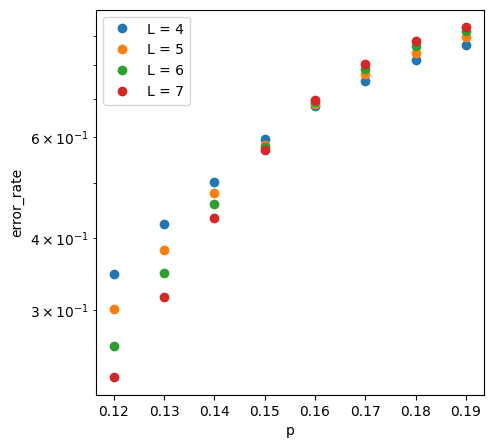

In [88]:
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

p = [0.12, 0.13, 0.14, 0.15, 0.16, 0.17, 0.18, 0.19]
L = [4, 5, 6, 7]

error_rate = np.array([np.mean(runs[:, 0:4, :], axis=(0, 1)),
                       np.mean(runs[:, 4:8, :], axis=(0, 1)),
                       np.mean(runs[:, 8:12, :], axis=(0, 1)),
                       np.mean(runs[:, 12:16, :], axis=(0, 1))])

plt.figure(figsize=(5, 5))
for l in range(len(L)):
    plt.plot(p, error_rate[l], 'o', label=f'L = {L[l]}')
    
plt.yscale('log')
plt.xlabel('p')
plt.ylabel('error_rate')
plt.legend()
plt.show()

In [89]:
from scipy.optimize import curve_fit

p = np.tile(np.array([0.12, 0.13, 0.14, 0.15, 0.16, 0.17, 0.18, 0.19]), 4)
L = np.repeat(np.array([4,5,6,7]), 8)
rate = error_rate.flatten()
n = 8000
rate_error = np.array([])
for i in range(len(p)):
    se = (rate[i]*(1-rate[i])/n)**(1/2)
    rate_error = np.append(rate_error, se)

In [90]:
# Define the model
def model(pL, pc, nu, A, B, C):
    p, L = pL
    return A + B*(p-pc)*(L**(1/nu)) + C*((p-pc)**2)*(L**(2/nu))

# Perform the fit with error bars
popt, pcov, infodict, mesg, ier = curve_fit(model, (p, L), rate, full_output=True, sigma=rate_error, absolute_sigma=True)

# Results
print("Fitted parameters:", popt)

# Calculate standard deviations of parameters
perr = np.sqrt(np.diag(pcov))
print("Parameter standard deviations:", perr)
np.sum(np.abs(infodict['fvec']))

Fitted parameters: [ 0.15559546  1.77331601  0.64148555  3.51132791 -5.65120195]
Parameter standard deviations: [0.00084626 0.05931465 0.00757283 0.11551282 0.42933155]


np.float64(81.56953870442834)

In [91]:
# Define the model
def model(pL, pc, nu, A, B, C, D):
    p, L = pL
    return A + B*(p-pc)*(L**(1/nu)) + C*((p-pc)**2)*(L**(2/nu)) + D*((p-pc)**3)*(L**(3/nu))

# Perform the fit with error bars
popt, pcov, infodict, mesg, ier = curve_fit(model, (p, L), rate, p0=[0.2, 1.5, 0.25, 0, 0, 0], full_output=True, sigma=rate_error, absolute_sigma=True)

# Results
print("Fitted parameters:", popt)

# Calculate standard deviations of parameters
perr = np.sqrt(np.diag(pcov))
print("Parameter standard deviations:", perr)
np.sum(np.abs(infodict['fvec']))

Fitted parameters: [  0.15550597   1.30304217   0.63663222   2.82457558  -2.38019158
 -23.95270151]
Parameter standard deviations: [6.66024086e-04 4.64339477e-02 6.80244041e-03 1.25858434e-01
 3.15166476e-01 3.07785209e+00]


np.float64(18.51248669588221)

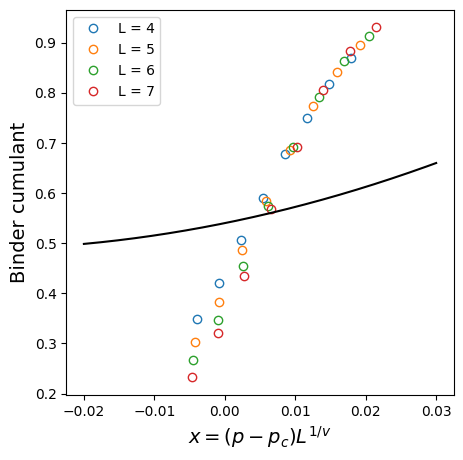

In [80]:
pc = 0.112518356
nu = 3.11337647
A = 0.539977570
B = 2.84733521
C = 38.5444815
D = -7.53489075

p = [0.11, 0.112, 0.114, 0.116, 0.118, 0.12, 0.122, 0.124]
L = [4, 5, 6, 7]
error_rate = np.array([np.mean(runs[:, 0:4, :], axis=(0, 1)),
                       np.mean(runs[:, 4:8, :], axis=(0, 1)),
                       np.mean(runs[:, 8:12, :], axis=(0, 1)),
                       np.mean(runs[:, 12:16, :], axis=(0, 1))])

x = np.zeros((len(L), len(p)))
plt.figure(figsize=(5, 5))
for l in range(len(L)):
    for i in range(len(p)):
        x[l][i] = (p[i]-pc) * (L[l]**(1/nu))
    plt.plot(x[l], error_rate[l], 'o', markerfacecolor='none', label=f'L = {L[l]}')
x_data = np.linspace(-0.02, 0.03, 1000)
y_data = A + B*x_data + C*(x_data**2) + D*(x_data**3)
plt.plot(x_data, y_data, color = 'k')

#ax = plt.gca()
#ax.spines['top'].set_visible(False)
#ax.spines['right'].set_visible(False)

#plt.yscale('log')
plt.xlabel('$x=(p-p_c)L^{1/v}$', fontsize=14)
plt.ylabel('Binder cumulant', fontsize=14)
plt.legend()
#plt.savefig('modified-D4.png', dpi=600, bbox_inches='tight')
plt.show()